In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import psycopg2
import warnings
warnings.filterwarnings('ignore')

# PostgreSQL connection
conn = psycopg2.connect(
    dbname="bluestock_mf",
    user="postgres",
    password="8128128208",
    host="localhost",
    port="5432"
)

# Load tables
dim_fund = pd.read_sql("SELECT scheme_code, scheme_name, category FROM dim_fund", conn)
dim_date = pd.read_sql("SELECT date_id, full_date FROM dim_date", conn)
fact_nav = pd.read_sql("SELECT scheme_code, date_id, nav_value FROM fact_nav", conn)

print("Data loaded")
print(f"dim_fund: {dim_fund.shape}")
print(f"fact_nav: {fact_nav.shape}")

# Merge to get dates and scheme names
nav_data = fact_nav.merge(dim_date, on='date_id')
nav_data = nav_data.merge(dim_fund, on='scheme_code')
nav_data['full_date'] = pd.to_datetime(nav_data['full_date'])
nav_data = nav_data.sort_values(['scheme_code', 'full_date'])

# Load benchmark indices (Nifty 100, Nifty 50)
processed_path = Path("data/processed")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")
print(benchmark.columns.tolist())
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark = benchmark.sort_values('date')

Data loaded
dim_fund: (40, 3)
fact_nav: (46000, 3)
['date', 'index_name', 'close_value']


Daily returns distribution (all funds combined):
Mean: 0.000631
Std: 0.010290
Min: -0.058102
Max: 0.064713


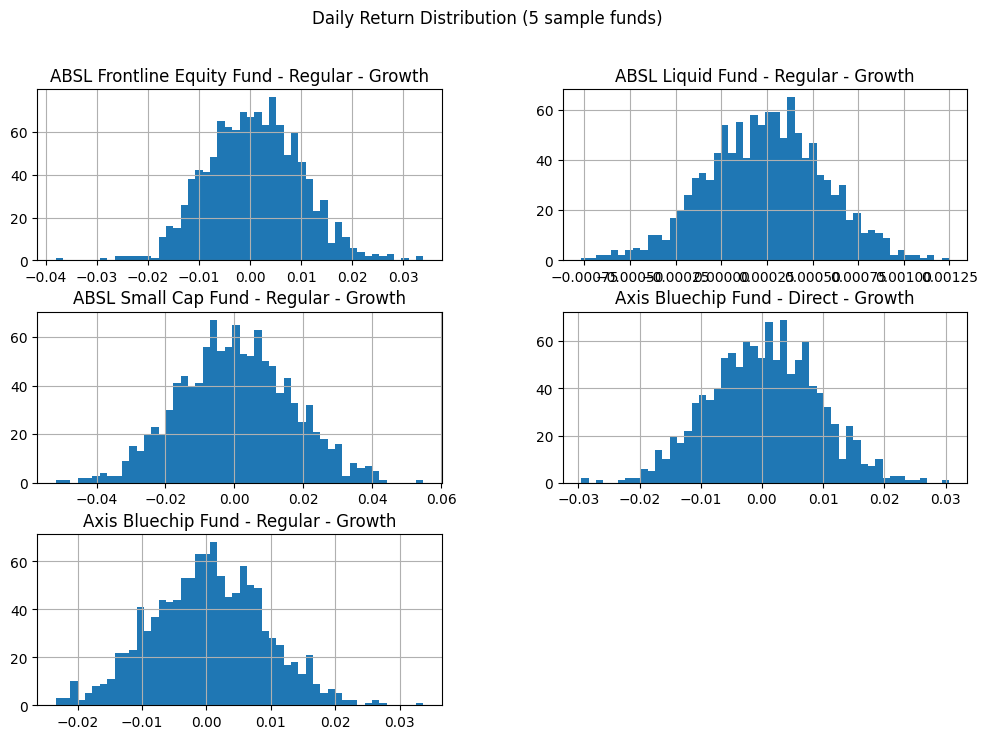

In [3]:
# Pivot to get scheme names as columns
nav_pivot = nav_data.pivot(index='full_date', columns='scheme_name', values='nav_value')
# Calculate daily returns (percentage change)
returns = nav_pivot.pct_change().dropna()

# Validate distribution - compute overall statistics across all schemes
all_returns = returns.values.flatten()
all_returns = all_returns[~np.isnan(all_returns)]

print("Daily returns distribution (all funds combined):")
print(f"Mean: {all_returns.mean():.6f}")
print(f"Std: {all_returns.std():.6f}")
print(f"Min: {all_returns.min():.6f}")
print(f"Max: {all_returns.max():.6f}")

# Plot distribution of returns for a few random schemes
import matplotlib.pyplot as plt
sample_schemes = returns.columns[:5]
sample_returns = returns[sample_schemes]
sample_returns.hist(bins=50, figsize=(12, 8))
plt.suptitle('Daily Return Distribution (5 sample funds)')
plt.show()

In [5]:
# Get latest NAV date
latest_date = returns.index.max()
# Define periods (years back)
cagr_periods = {
    '1Y': 365,
    '3Y': 3*365,
    '5Y': 5*365
}

cagr_results = []

for scheme in returns.columns:
    scheme_nav = nav_pivot[scheme].dropna()
    latest_nav = scheme_nav.iloc[-1]
    for period_name, days in cagr_periods.items():
        # Find NAV approximately 'days' ago
        target_date = latest_date - pd.Timedelta(days=days)
        # Get NAV at closest date to target_date
        idx = scheme_nav.index.get_indexer([target_date], method='nearest')[0]
        if idx >= 0:
            past_nav = scheme_nav.iloc[idx]
            actual_days = (scheme_nav.index[-1] - scheme_nav.index[idx]).days
            if actual_days > 0 and past_nav > 0:
                cagr = (latest_nav / past_nav) ** (365/actual_days) - 1
            else:
                cagr = np.nan
        else:
            cagr = np.nan
        cagr_results.append({
            'scheme_name': scheme,
            'period': period_name,
            'cagr_pct': cagr * 100
        })

cagr_df = pd.DataFrame(cagr_results)
cagr_pivot = cagr_df.pivot(index='scheme_name', columns='period', values='cagr_pct')
print("CAGR comparison (top 10 funds by 3Y):")
print(cagr_pivot.sort_values('3Y', ascending=False).head(10))

CAGR comparison (top 10 funds by 3Y):
period                                                     1Y         3Y  \
scheme_name                                                                
Axis Midcap Fund - Regular - Growth                 22.261065  35.334366   
Mirae Asset Large Cap Fund - Regular - Growth       20.360678  34.162703   
ICICI Pru Bluechip Fund - Direct - Growth           13.064279  33.144774   
HDFC Mid-Cap Opportunities Fund - Regular - Growth  53.232396  32.446898   
ICICI Pru Midcap Fund - Regular - Growth            29.604659  31.517893   
SBI Bluechip Fund - Regular Plan - Growth           60.437341  30.348209   
Kotak Flexicap Fund - Regular - Growth              26.657082  29.691888   
ABSL Frontline Equity Fund - Regular - Growth       47.924120  28.669133   
Mirae Asset Tax Saver Fund - Regular - Growth       39.751761  28.392402   
DSP Small Cap Fund - Regular - Growth               65.138719  26.931965   

period                                           

In [6]:
rf_annual = 0.065  # 6.5%
rf_daily = (1 + rf_annual) ** (1/252) - 1

sharpe_results = []
for scheme in returns.columns:
    excess_daily = returns[scheme] - rf_daily
    sharpe = excess_daily.mean() / excess_daily.std() * np.sqrt(252)
    sharpe_results.append({'scheme_name': scheme, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_results).sort_values('sharpe_ratio', ascending=False)
print("Top 10 funds by Sharpe Ratio:")
print(sharpe_df.head(10))

Top 10 funds by Sharpe Ratio:
                                          scheme_name  sharpe_ratio
25      Mirae Asset Large Cap Fund - Regular - Growth      1.462504
22             Kotak Flexicap Fund - Regular - Growth      1.319442
26      Mirae Asset Tax Saver Fund - Regular - Growth      1.246344
33          SBI Bluechip Fund - Regular Plan - Growth      1.222947
18           ICICI Pru Midcap Fund - Regular - Growth      1.190559
7                  DSP Midcap Fund - Regular - Growth      1.143490
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.104352
30     Nippon India Large Cap Fund - Regular - Growth      1.095918
0       ABSL Frontline Equity Fund - Regular - Growth      1.041061
15          ICICI Pru Bluechip Fund - Direct - Growth      1.040569


In [7]:
sortino_results = []
for scheme in returns.columns:
    downside = returns[scheme][returns[scheme] < 0]
    if len(downside) > 0:
        downside_std = downside.std()
        excess_daily = returns[scheme] - rf_daily
        sortino = excess_daily.mean() / downside_std * np.sqrt(252)
    else:
        sortino = np.nan
    sortino_results.append({'scheme_name': scheme, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_results).sort_values('sortino_ratio', ascending=False)
print("Top 10 funds by Sortino Ratio:")
print(sortino_df.head(10))

Top 10 funds by Sortino Ratio:
                                          scheme_name  sortino_ratio
25      Mirae Asset Large Cap Fund - Regular - Growth       2.409056
22             Kotak Flexicap Fund - Regular - Growth       2.387295
26      Mirae Asset Tax Saver Fund - Regular - Growth       2.166757
33          SBI Bluechip Fund - Regular Plan - Growth       2.166272
18           ICICI Pru Midcap Fund - Regular - Growth       2.047336
17           ICICI Pru Liquid Fund - Regular - Growth       1.918995
7                  DSP Midcap Fund - Regular - Growth       1.893929
30     Nippon India Large Cap Fund - Regular - Growth       1.874521
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...       1.846950
15          ICICI Pru Bluechip Fund - Direct - Growth       1.829993


In [9]:
# Load benchmark indices (assuming columns: 'date', 'nifty_50', 'nifty_100')
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark = benchmark.sort_values('date')

# Identify index columns (values, not returns)
index_cols = [c for c in benchmark.columns if 'nifty' in c.lower() or 'benchmark' in c.lower()]
print("Index columns found:", index_cols)

# Calculate daily returns for each benchmark index
bench_returns = pd.DataFrame()
bench_returns['date'] = benchmark['date']
for col in index_cols:
    bench_returns[f'{col}_return'] = benchmark[col].pct_change()
bench_returns = bench_returns.set_index('date').dropna()

# Choose the first benchmark column (e.g., nifty_100) as the primary
bench_col = [c for c in bench_returns.columns if 'nifty_100' in c.lower() or 'nifty_100' in c.lower()]
if not bench_col:
    bench_col = bench_returns.columns[0]  # fallback to first column
else:
    bench_col = bench_col[0]
print(f"Using benchmark column: {bench_col}")
bench_returns_series = bench_returns[bench_col]

# Align dates with fund returns
common_dates = returns.index.intersection(bench_returns_series.index)
X = bench_returns_series.loc[common_dates].values
alpha_beta_results = []

for scheme in returns.columns:
    y = returns[scheme].loc[common_dates].values
    if len(y) > 0 and not np.isnan(y).any():
        slope, intercept, r_value, p_value, std_err = linregress(X, y)
        beta = slope
        alpha_annual = intercept * 252  # annualized alpha
        alpha_beta_results.append({
            'scheme_name': scheme,
            'alpha_annual_pct': alpha_annual * 100,
            'beta': beta,
            'r_squared': r_value**2
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print("Alpha & Beta (vs Nifty 100):")
print(alpha_beta_df.sort_values('alpha_annual_pct', ascending=False).head(10))
# Save to CSV
alpha_beta_df.to_csv(processed_path / "alpha_beta.csv", index=False)
print("\nSaved alpha_beta.csv")

Index columns found: []


IndexError: index 0 is out of bounds for axis 0 with size 0

In [11]:
from scipy.stats import linregress
from pathlib import Path

processed_path = Path("data/processed")

# Load benchmark data (long format: date, index_name, close_value)
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Pivot so each index becomes a column
bench_pivot = benchmark.pivot(index='date', columns='index_name', values='close_value')
print("Benchmark indices:", bench_pivot.columns.tolist())

# Calculate daily returns for each index
bench_returns = bench_pivot.pct_change().dropna()

# Choose a benchmark column – prefer NIFTY100 if exists, else NIFTY50
if 'NIFTY100' in bench_returns.columns:
    bench_col = 'NIFTY100'
elif 'NIFTY 100' in bench_returns.columns:
    bench_col = 'NIFTY 100'
else:
    bench_col = bench_returns.columns[0]  # fallback to first (usually NIFTY50)
print(f"Using benchmark: {bench_col}")

bench_returns_series = bench_returns[bench_col].dropna()

# Align dates with fund returns
common_dates = returns.index.intersection(bench_returns_series.index)
X = bench_returns_series.loc[common_dates].values
alpha_beta_results = []

for scheme in returns.columns:
    y = returns[scheme].loc[common_dates].values
    if len(y) > 0 and not np.isnan(y).any():
        slope, intercept, r_value, p_value, std_err = linregress(X, y)
        beta = slope
        alpha_annual = intercept * 252  # annualized alpha
        alpha_beta_results.append({
            'scheme_name': scheme,
            'alpha_annual_pct': alpha_annual * 100,
            'beta': beta,
            'r_squared': r_value**2
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print("Alpha & Beta (vs NIFTY100):")
print(alpha_beta_df.sort_values('alpha_annual_pct', ascending=False).head(10))

# Save to CSV
alpha_beta_df.to_csv(processed_path / "alpha_beta.csv", index=False)
print("\nSaved alpha_beta.csv")

Benchmark indices: ['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']
Using benchmark: NIFTY100
Alpha & Beta (vs NIFTY100):
                                          scheme_name  alpha_annual_pct  \
36         SBI Small Cap Fund - Regular Plan - Growth         30.336965   
8               DSP Small Cap Fund - Regular - Growth         30.057878   
18           ICICI Pru Midcap Fund - Regular - Growth         29.263583   
26      Mirae Asset Tax Saver Fund - Regular - Growth         28.270368   
22             Kotak Flexicap Fund - Regular - Growth         27.330465   
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         27.195355   
25      Mirae Asset Large Cap Fund - Regular - Growth         26.983751   
7                  DSP Midcap Fund - Regular - Growth         26.598578   
5                 Axis Midcap Fund - Regular - Growth         26.076669   
33          SBI Bluechip Fund - Regular Plan - Growth         23.201007   

In [12]:
drawdown_results = []
for scheme in returns.columns:
    nav_series = nav_pivot[scheme].dropna()
    running_max = nav_series.expanding().max()
    drawdown = (nav_series - running_max) / running_max
    max_dd = drawdown.min()
    # Find date range of max drawdown
    start_idx = drawdown.idxmin()
    # Find when it started (previous peak)
    peak_date = running_max[running_max == running_max.loc[start_idx]].index[0] if len(running_max[running_max == running_max.loc[start_idx]]) > 0 else start_idx
    drawdown_results.append({
        'scheme_name': scheme,
        'max_drawdown_pct': max_dd * 100,
        'peak_date': peak_date,
        'trough_date': start_idx
    })
dd_df = pd.DataFrame(drawdown_results).sort_values('max_drawdown_pct')
print("Funds with least drawdown (best):")
print(dd_df.head(10))

Funds with least drawdown (best):
                                       scheme_name  max_drawdown_pct  \
35       SBI Small Cap Fund - Direct Plan - Growth        -52.574221   
6           Axis Small Cap Fund - Regular - Growth        -51.677754   
2           ABSL Small Cap Fund - Regular - Growth        -35.446916   
8            DSP Small Cap Fund - Regular - Growth        -31.171900   
36      SBI Small Cap Fund - Regular Plan - Growth        -28.706006   
38             UTI Mid Cap Fund - Regular - Growth        -28.001124   
14       HDFC Top 100 Fund - Regular Plan - Growth        -24.734441   
21   Kotak Emerging Equity Fund - Regular - Growth        -24.003511   
31  Nippon India Small Cap Fund - Regular - Growth        -23.344886   
3             Axis Bluechip Fund - Direct - Growth        -21.751396   

    peak_date trough_date  
35 2023-01-17  2025-10-28  
6  2025-05-22  2026-05-11  
2  2024-11-21  2026-05-11  
8  2024-05-03  2025-01-03  
36 2024-08-28  2025-05-14  
38 20

In [13]:
# Merge all metrics
scorecard = cagr_pivot[['3Y']].rename(columns={'3Y': 'cagr_3y'})
scorecard = scorecard.merge(sharpe_df.set_index('scheme_name'), left_index=True, right_index=True)
scorecard = scorecard.merge(alpha_beta_df.set_index('scheme_name')['alpha_annual_pct'], left_index=True, right_index=True)
# Expense ratio (from dim_fund? If not available, we skip expense ratio component)
# For now, we assume expense ratio is not in dim_fund (we can use scheme_performance cleaned)
# Load scheme_performance cleaned
perf_clean = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
expense = perf_clean[['scheme_name', 'expense_ratio_pct']].drop_duplicates('scheme_name')
scorecard = scorecard.merge(expense.set_index('scheme_name'), left_index=True, right_index=True)
scorecard = scorecard.merge(dd_df.set_index('scheme_name')['max_drawdown_pct'], left_index=True, right_index=True)

# Rank (higher rank = better)
scorecard['cagr_rank'] = scorecard['cagr_3y'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha_annual_pct'].rank(ascending=False)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)  # lower expense better
scorecard['dd_rank'] = scorecard['max_drawdown_pct'].rank(ascending=True)  # less drawdown better

# Weights
w_cagr = 0.30
w_sharpe = 0.25
w_alpha = 0.20
w_expense = 0.15
w_dd = 0.10

scorecard['score'] = (w_cagr * scorecard['cagr_rank'] +
                      w_sharpe * scorecard['sharpe_rank'] +
                      w_alpha * scorecard['alpha_rank'] +
                      w_expense * scorecard['expense_rank'] +
                      w_dd * scorecard['dd_rank']) / (w_cagr + w_sharpe + w_alpha + w_expense + w_dd)

# Normalize to 0-100
scorecard['score_100'] = (scorecard['score'] / scorecard['score'].max()) * 100
scorecard = scorecard.sort_values('score_100', ascending=False)
print("Top 10 Funds by Overall Score (0-100):")
print(scorecard[['cagr_3y', 'sharpe_ratio', 'alpha_annual_pct', 'expense_ratio_pct', 'max_drawdown_pct', 'score_100']].head(10))

# Save to CSV
scorecard[['cagr_3y', 'sharpe_ratio', 'alpha_annual_pct', 'expense_ratio_pct', 'max_drawdown_pct', 'score_100']].to_csv(processed_path / "fund_scorecard.csv")
print("\nSaved fund_scorecard.csv")

Top 10 Funds by Overall Score (0-100):
                                                      cagr_3y  sharpe_ratio  \
scheme_name                                                                   
HDFC Top 100 Fund - Regular Plan - Growth            1.030698     -0.187650   
Axis Bluechip Fund - Regular - Growth                1.228603      0.045245   
UTI Mid Cap Fund - Regular - Growth                 -0.951441     -0.194707   
HDFC Short Term Debt Fund - Regular - Growth         3.902496     -0.515438   
ABSL Liquid Fund - Regular - Growth                  6.315130     -0.417229   
Axis Small Cap Fund - Regular - Growth             -10.939403     -0.067926   
Nippon India Gilt Securities Fund - Regular - G...   3.828362     -0.306013   
SBI Magnum Gilt Fund - Regular Plan - Growth         5.913773     -0.175723   
ABSL Small Cap Fund - Regular - Growth              -4.693652      0.170481   
Kotak Emerging Equity Fund - Regular - Growth        6.902588      0.087273   

            

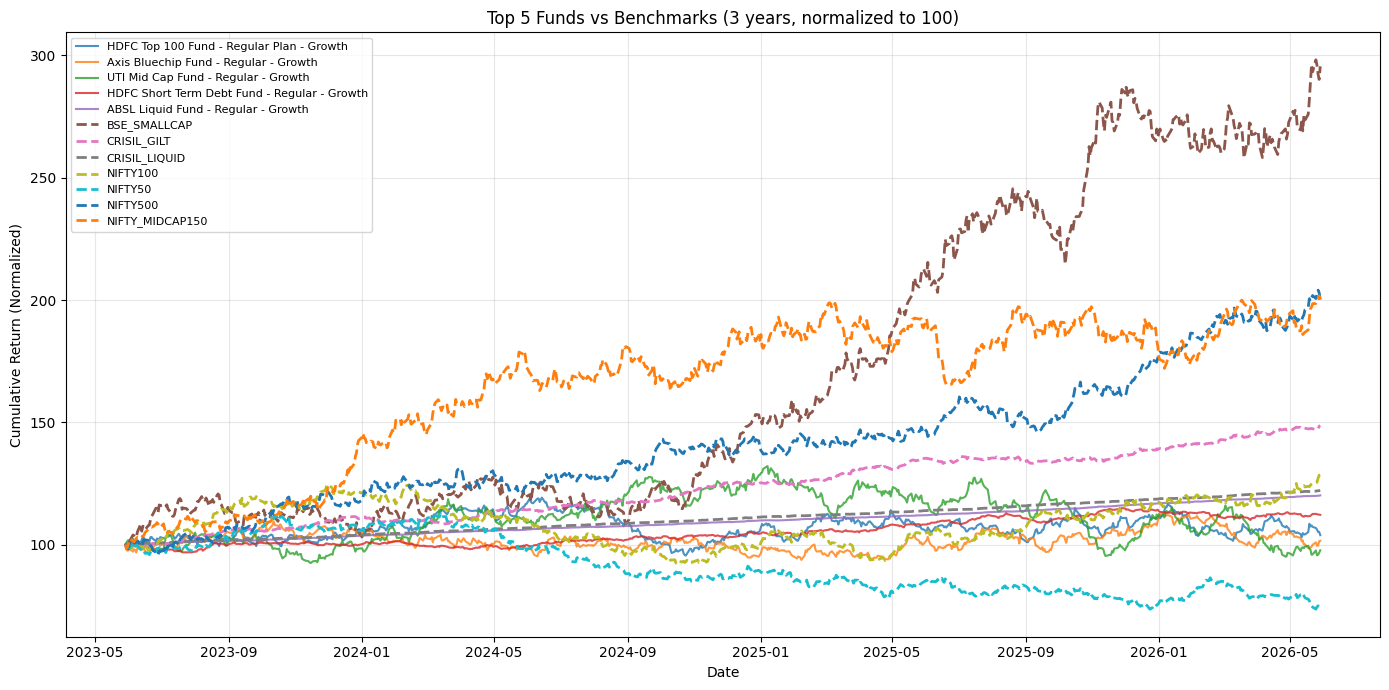

In [14]:
# Get top 5 funds by 3Y CAGR
top_5 = scorecard.head(5).index.tolist()

# Filter NAV data for last 3 years
three_years_ago = returns.index.max() - pd.DateOffset(years=3)
nav_last3y = nav_pivot.loc[nav_pivot.index >= three_years_ago]
# Normalize to start at 100
nav_normalized = nav_last3y.div(nav_last3y.iloc[0]) * 100

# Use the same pivoted benchmark data from above
benchmark_prices = bench_pivot.copy()  # from previous cell
benchmark_prices = benchmark_prices.loc[benchmark_prices.index >= three_years_ago]

# Normalize benchmarks
bench_normalized = benchmark_prices.div(benchmark_prices.iloc[0]) * 100

# Plot
plt.figure(figsize=(14, 7))
for scheme in top_5:
    plt.plot(nav_normalized.index, nav_normalized[scheme], label=scheme, alpha=0.8)

# Plot all available benchmark indices (e.g., NIFTY50, NIFTY100)
for col in bench_normalized.columns:
    plt.plot(bench_normalized.index, bench_normalized[col], '--', label=col, linewidth=2)

plt.title('Top 5 Funds vs Benchmarks (3 years, normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Normalized)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(processed_path / "benchmark_comparison.png", dpi=150)
plt.show()

In [16]:
# Compute tracking error for top funds vs NIFTY100
# Ensure bench_returns_series is from Cell 6
tracking_errors = []
three_years_ago = returns.index.max() - pd.DateOffset(years=3)

# Get benchmark returns for last 3 years
bench_returns_3y = bench_returns_series[bench_returns_series.index >= three_years_ago]

# Ensure top_5 is defined (if not, get from scorecard)
if 'top_5' not in dir():
    top_5 = scorecard.head(5).index.tolist()

for scheme in top_5:
    fund_returns_3y = returns[scheme].loc[bench_returns_3y.index]
    diff = fund_returns_3y - bench_returns_3y
    te = diff.std() * np.sqrt(252)
    tracking_errors.append({'scheme_name': scheme, 'tracking_error_annual': te})

te_df = pd.DataFrame(tracking_errors).sort_values('tracking_error_annual')
print("Tracking Error (vs NIFTY100) – lower is better:")
print(te_df)

Tracking Error (vs NIFTY100) – lower is better:
                                    scheme_name  tracking_error_annual
4           ABSL Liquid Fund - Regular - Growth               0.127640
3  HDFC Short Term Debt Fund - Regular - Growth               0.133607
1         Axis Bluechip Fund - Regular - Growth               0.185821
0     HDFC Top 100 Fund - Regular Plan - Growth               0.195345
2           UTI Mid Cap Fund - Regular - Growth               0.223295


In [17]:
print("All deliverables saved:")
print(f"  - fund_scorecard.csv: {processed_path / 'fund_scorecard.csv'}")
print(f"  - alpha_beta.csv: {processed_path / 'alpha_beta.csv'}")
print(f"  - benchmark_comparison.png: {processed_path / 'benchmark_comparison.png'}")

All deliverables saved:
  - fund_scorecard.csv: data\processed\fund_scorecard.csv
  - alpha_beta.csv: data\processed\alpha_beta.csv
  - benchmark_comparison.png: data\processed\benchmark_comparison.png
